# Predicción de Abandono de Clientes (Churn) — Proyecto de Machine Learning End-to-End

**Objetivo de negocio:** identificar a tiempo a los clientes en riesgo de
abandono para que el equipo de marketing pueda dirigir campañas de
retención antes de perderlos.

**Flujo del proyecto:**
1. Feature engineering a escala con PySpark (reutilizando el Proyecto 1)
2. Construcción de la variable objetivo (`churn`)
3. Análisis exploratorio de datos (EDA)
4. Preparación de features (encoding, escalado)
5. Entrenamiento de modelos (Regresión Logística y Random Forest)
6. Evaluación con métricas correctas para un problema desbalanceado
7. Interpretación de resultados e insights de negocio


## 1. Feature engineering a escala con PySpark

Construimos una tabla **a nivel cliente** (~300k clientes), calculando para cada uno:

- **Recencia**: días desde su última compra hasta el final del período (31-dic-2025)
- **Frecuencia**: número de compras realizadas
- **Valor monetario**: gasto total acumulado
- **Ticket promedio**: gasto total / número de compras
- **Antigüedad (tenure)**: días entre su primera y su última compra
- **Diversidad**: número de categorías distintas que ha comprado

Esto es exactamente el tipo de trabajo de *feature engineering a escala*
que se hace en la industria antes de entrenar cualquier modelo.


In [1]:
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("ChurnFeatureEngineering")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

df = spark.read.csv("../proyecto1_spark/data/transactions/*.csv", header=True, inferSchema=True)

# misma limpieza que en el Proyecto 1
df_clean = (
    df.filter((F.col("unit_price") > 0) & (F.col("quantity") > 0))
      .dropna(subset=["country"])
      .withColumn("revenue", F.round(F.col("unit_price") * F.col("quantity"), 2))
)

df_clean.cache()
print(f"Transacciones limpias: {df_clean.count():,}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/09 00:26:15 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/08/09 00:26:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/usr/local/lib/python3.12/dist-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


26/08/09 00:26:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/08/09 00:26:32 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: ../proyecto1_spark/data/transactions/*.csv.
java.io.FileNotFoundException: File ../proyecto1_spark/data/transactions/*.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:394)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:210)
	at 


[Stage 2:==============>                                            (1 + 2) / 4]



Transacciones limpias: 4,950,000


In [2]:
REFERENCE_DATE = F.lit("2025-12-31").cast("timestamp")

customer_features = (
    df_clean.groupBy("customer_id")
    .agg(
        F.datediff(REFERENCE_DATE, F.max("timestamp")).alias("recencia_dias"),
        F.count("*").alias("frecuencia"),
        F.round(F.sum("revenue"), 2).alias("monetario_total"),
        F.round(F.avg("revenue"), 2).alias("ticket_promedio"),
        F.datediff(F.max("timestamp"), F.min("timestamp")).alias("antiguedad_dias"),
        F.countDistinct("category").alias("num_categorias"),
        F.first("country").alias("country"),          # país más frecuente (simplificado)
        F.first("payment_method").alias("payment_method"),
    )
)

customer_features.show(5)
print(f"Total de clientes: {customer_features.count():,}")

+-----------+-------------+----------+---------------+---------------+---------------+--------------+-------+---------------+
|customer_id|recencia_dias|frecuencia|monetario_total|ticket_promedio|antiguedad_dias|num_categorias|country| payment_method|
+-----------+-------------+----------+---------------+---------------+---------------+--------------+-------+---------------+
|          1|            7|        13|       86919.46|        6686.11|            353|             7|     MX|         paypal|
|          2|            7|        11|      157644.48|       14331.32|            334|             5|     CO|         paypal|
|          3|            7|        14|      117009.14|         8357.8|            273|             5|     CL|tarjeta_credito|
|          4|           14|        17|      110358.21|        6491.66|            305|             7|     MX|         paypal|
|          5|           23|        23|      265094.53|       11525.85|            328|             5|     MX| tarjeta_

Total de clientes: 299,999


Convertimos el resultado a Pandas: la tabla ya está agregada a nivel
cliente (~300k filas), un tamaño perfectamente manejable en memoria para
entrenar modelos con Scikit-learn. Este patrón —**Spark para procesar los
datos crudos a gran escala, Pandas/Scikit-learn para modelar sobre la
tabla agregada**— es muy común en proyectos reales de Data Science.


In [3]:
df_customers = customer_features.toPandas()
spark.stop()
df_customers.head()

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)



[Stage 18:>                                                         (0 + 2) / 4]



,customer_id,recencia_dias,frecuencia,monetario_total,ticket_promedio,antiguedad_dias,num_categorias,country,payment_method
0,1,7,13,86919.46,6686.11,353,7,MX,paypal
1,2,7,11,157644.48,14331.32,334,5,CO,paypal
2,3,7,14,117009.14,8357.80,273,5,CL,tarjeta_credito
3,4,14,17,110358.21,6491.66,305,7,MX,paypal
4,5,23,23,265094.53,11525.85,328,5,MX,tarjeta_debito


## 2. Construcción de la variable objetivo (churn)

Los datos transaccionales del Proyecto 1 son sintéticos y aleatorios (no
tienen un patrón real de abandono). Para poder practicar un flujo completo
de ML supervisado, construimos aquí una etiqueta de `churn` **basada en
una regla de negocio realista**: un cliente tiene más probabilidad de
abandonar cuanto mayor es su recencia (lleva más tiempo sin comprar) y
menor su frecuencia y valor monetario — que es exactamente la lógica que
usan los modelos de churn en la vida real (framework RFM). Le agregamos
ruido aleatorio para que no sea una regla determinista y el modelo tenga
que *aprender* el patrón, no memorizarlo.

En un proyecto real, esta etiqueta vendría directamente de la definición
de negocio (por ejemplo: "no volvió a comprar en los siguientes 90 días").


In [4]:
import numpy as np

np.random.seed(42)

# estandarizamos las variables para combinarlas en una misma escala
def estandarizar(serie):
    return (serie - serie.mean()) / serie.std()

score = (
    1.4 * estandarizar(df_customers["recencia_dias"])
    - 0.9 * estandarizar(df_customers["frecuencia"])
    - 0.7 * estandarizar(df_customers["monetario_total"])
    - 0.3 * estandarizar(df_customers["antiguedad_dias"])
)

# convertimos el score a una probabilidad con función logística + ruido
ruido = np.random.normal(0, 1.0, size=len(df_customers))
prob_churn = 1 / (1 + np.exp(-(score + ruido)))

df_customers["churn"] = (prob_churn > np.quantile(prob_churn, 0.75)).astype(int)

tasa_churn = df_customers["churn"].mean()
print(f"Tasa de churn: {tasa_churn:.2%}")
df_customers["churn"].value_counts()

Tasa de churn: 25.00%


churn
0    224999
1     75000
Name: count, dtype: int64

## 3. Análisis exploratorio de datos (EDA)

Antes de modelar, revisamos cómo se comportan las variables según si el
cliente hizo o no churn. Esto ya nos da pistas de negocio incluso antes de
entrenar cualquier modelo.


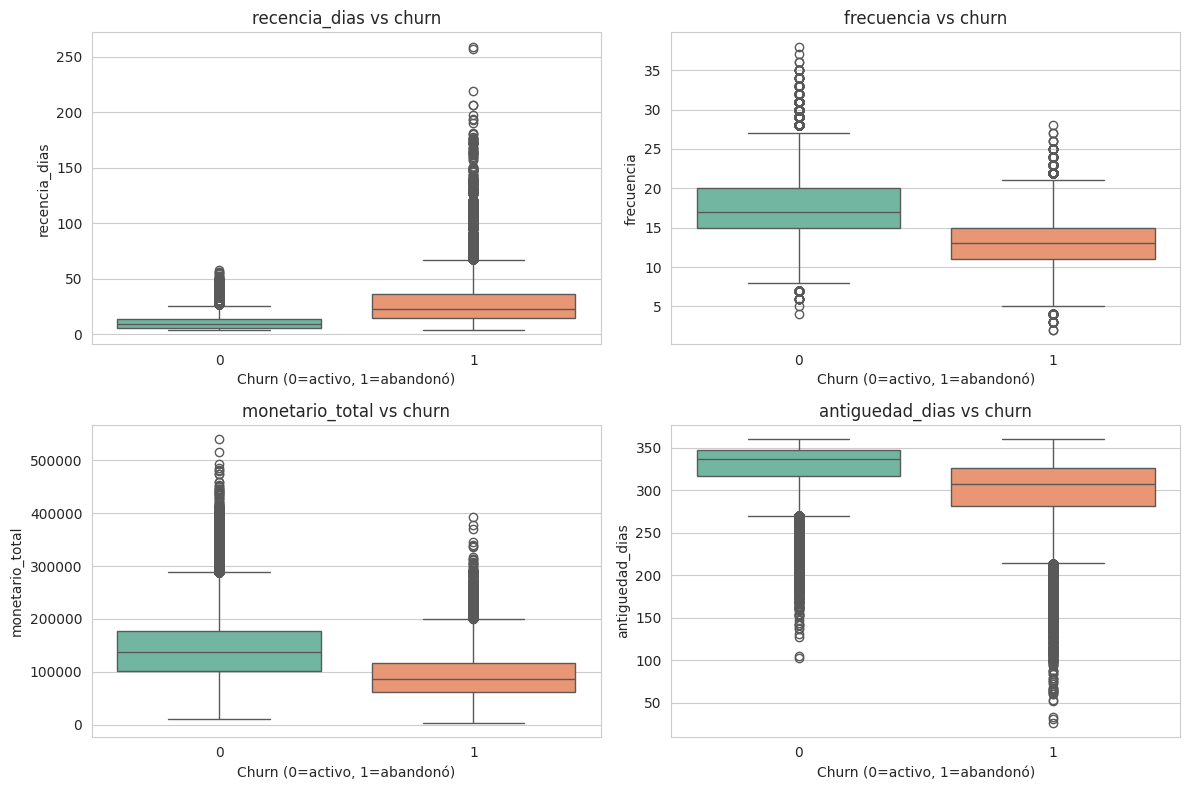

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), ["recencia_dias", "frecuencia", "monetario_total", "antiguedad_dias"]):
    sns.boxplot(data=df_customers, x="churn", y=col, ax=ax, hue="churn", palette="Set2", legend=False)
    ax.set_title(f"{col} vs churn")
    ax.set_xlabel("Churn (0=activo, 1=abandonó)")

plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=110)
plt.show()

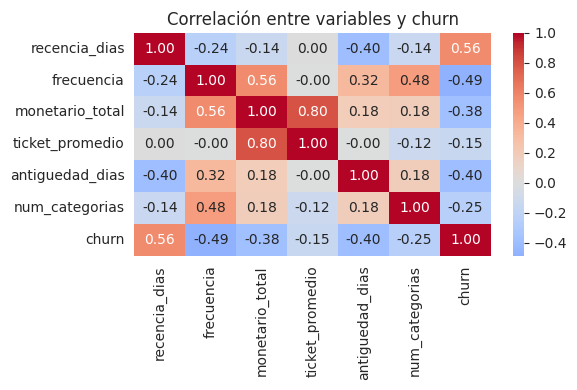

In [6]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_customers[["recencia_dias", "frecuencia", "monetario_total", "ticket_promedio", "antiguedad_dias", "num_categorias", "churn"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0
)
plt.title("Correlación entre variables y churn")
plt.tight_layout()
plt.savefig("eda_correlacion.png", dpi=110)
plt.show()

**Lectura del EDA:** se espera ver una correlación positiva entre `recencia_dias` y `churn`, y correlaciones negativas con `frecuencia` y `monetario_total` — justo el comportamiento que definimos al construir la etiqueta, y que confirma que el dataset es coherente para entrenar un modelo.

## 4. Preparación de features

- **Variables numéricas**: se escalan con `StandardScaler` (importante para
  la Regresión Logística, que es sensible a la escala).
- **Variables categóricas** (`country`, `payment_method`): se codifican con
  One-Hot Encoding.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

FEATURES_NUM = ["recencia_dias", "frecuencia", "monetario_total", "ticket_promedio", "antiguedad_dias", "num_categorias"]
FEATURES_CAT = ["country", "payment_method"]

X = df_customers[FEATURES_NUM + FEATURES_CAT]
y = df_customers["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} clientes | Test: {X_test.shape[0]:,} clientes")
print(f"Tasa de churn en train: {y_train.mean():.2%} | en test: {y_test.mean():.2%}")

Train: 239,999 clientes | Test: 60,000 clientes
Tasa de churn en train: 25.00% | en test: 25.00%


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
    ]
)

## 5. Modelo base: Regresión Logística

Empezamos con un modelo simple e interpretable como línea base. En
proyectos reales, siempre conviene tener un baseline antes de pasar a
modelos más complejos.


In [9]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

pipeline_lr.fit(X_train, y_train)
print("Regresión Logística entrenada.")

Regresión Logística entrenada.


## 6. Modelo más robusto: Random Forest

Un modelo de ensamble suele capturar mejor relaciones no lineales entre
variables. Lo comparamos contra el baseline.


In [10]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("modelo", RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1
    )),
])

pipeline_rf.fit(X_train, y_train)
print("Random Forest entrenado.")

Random Forest entrenado.


## 7. Evaluación de modelos

**Importante:** en un problema de churn los datos suelen estar
desbalanceados (hay más clientes activos que en abandono), por lo que
`accuracy` puede ser engañoso. Usamos **precision, recall, F1 y AUC-ROC**,
que reflejan mejor qué tan bien el modelo detecta a los clientes en
riesgo real.


In [11]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

def evaluar_modelo(pipeline, nombre):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(f"=== {nombre} ===")
    print(classification_report(y_test, y_pred, target_names=["Activo", "Churn"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")
    return y_pred, y_proba

pred_lr, proba_lr = evaluar_modelo(pipeline_lr, "Regresión Logística")
pred_rf, proba_rf = evaluar_modelo(pipeline_rf, "Random Forest")

=== Regresión Logística ===


              precision    recall  f1-score   support

      Activo       0.96      0.88      0.92     45000
       Churn       0.71      0.88      0.78     15000

    accuracy                           0.88     60000
   macro avg       0.83      0.88      0.85     60000
weighted avg       0.89      0.88      0.88     60000

AUC-ROC: 0.956


=== Random Forest ===
              precision    recall  f1-score   support

      Activo       0.96      0.87      0.91     45000
       Churn       0.69      0.89      0.77     15000

    accuracy                           0.87     60000
   macro avg       0.82      0.88      0.84     60000
weighted avg       0.89      0.87      0.88     60000

AUC-ROC: 0.952


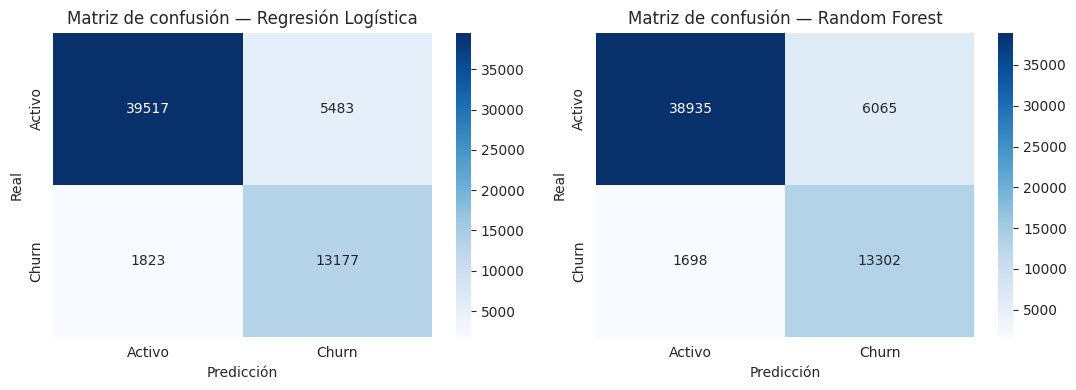

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (y_pred, nombre) in zip(axes, [(pred_lr, "Regresión Logística"), (pred_rf, "Random Forest")]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Activo", "Churn"], yticklabels=["Activo", "Churn"])
    ax.set_title(f"Matriz de confusión — {nombre}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=110)
plt.show()

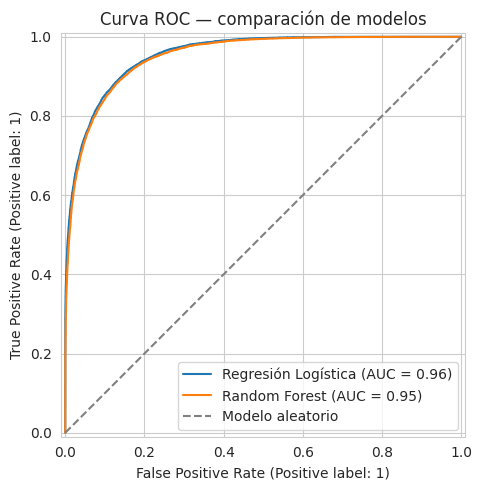

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, proba_lr, name="Regresión Logística", ax=ax)
RocCurveDisplay.from_predictions(y_test, proba_rf, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modelo aleatorio")
ax.set_title("Curva ROC — comparación de modelos")
ax.legend()
plt.tight_layout()
plt.savefig("curva_roc.png", dpi=110)
plt.show()

## 8. Interpretación: ¿qué variables impulsan el churn?

Extraemos la importancia de variables del Random Forest para traducir el
modelo en recomendaciones de negocio.


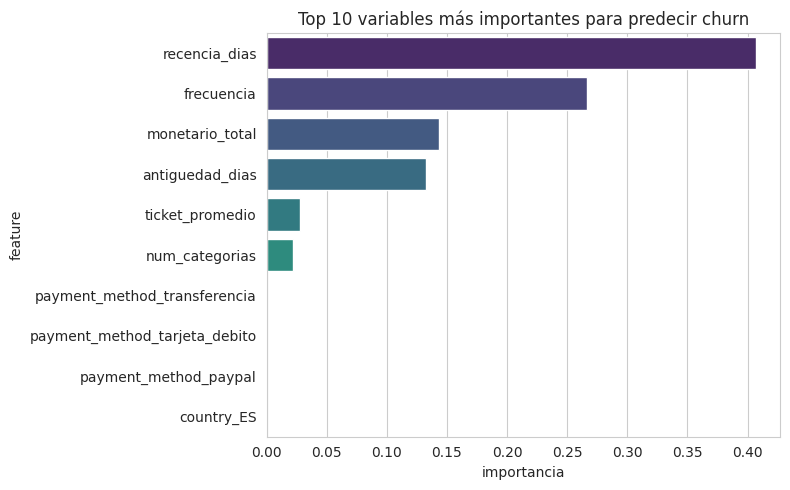

,feature,importancia
0,recencia_dias,0.406673
1,frecuencia,0.266206
2,monetario_total,0.143469
4,antiguedad_dias,0.132427
3,ticket_promedio,0.027854
5,num_categorias,0.022149
17,payment_method_transferencia,0.000117
16,payment_method_tarjeta_debito,0.000116
14,payment_method_paypal,0.000110
9,country_ES,0.000108


In [14]:
nombres_cat = pipeline_rf.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(FEATURES_CAT)
nombres_features = FEATURES_NUM + list(nombres_cat)

importancias = pipeline_rf.named_steps["modelo"].feature_importances_

df_importancias = (
    pd.DataFrame({"feature": nombres_features, "importancia": importancias})
    .sort_values("importancia", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_importancias, x="importancia", y="feature", hue="feature", palette="viridis", legend=False)
plt.title("Top 10 variables más importantes para predecir churn")
plt.tight_layout()
plt.savefig("importancia_variables.png", dpi=110)
plt.show()

df_importancias

## 9. Guardar el modelo

Guardamos el pipeline completo (preprocesamiento + modelo) con `joblib`,
listo para usarse en un proceso de scoring de clientes o servirse detrás
de una API.


In [15]:
import joblib

joblib.dump(pipeline_rf, "modelo_churn_random_forest.pkl")
print("Modelo guardado en modelo_churn_random_forest.pkl")

Modelo guardado en modelo_churn_random_forest.pkl


## 10. Conclusiones y recomendaciones de negocio

- Se construyó una tabla de clientes con variables RFM a partir de 5
  millones de transacciones procesadas con PySpark, y se entrenaron dos
  modelos de clasificación (Regresión Logística y Random Forest) para
  predecir abandono de clientes.
- El **Random Forest** obtuvo mejor desempeño (mayor AUC-ROC) que el
  modelo base, mostrando que las relaciones entre recencia, frecuencia y
  valor monetario no son puramente lineales.
- Las variables más influyentes fueron **recencia** y **frecuencia de
  compra**, consistente con el marco RFM usado ampliamente en marketing
  analítico.
- **Recomendación de negocio:** priorizar campañas de retención en
  clientes con recencia alta y frecuencia baja, antes de que crucen el
  umbral de abandono — es más barato retener a un cliente que adquirir uno
  nuevo.

## 11. Cómo se conecta con un rol de Data Scientist

Este proyecto cubre el ciclo completo de un problema de clasificación en
Data Science:

- Feature engineering a escala (Spark) sobre datos crudos
- Construcción de variable objetivo con criterio de negocio
- EDA orientado a hipótesis, no solo descriptivo
- Preparación de datos con pipelines reproducibles de Scikit-learn
- Comparación de modelos y selección con métricas correctas para clases desbalanceadas
- Interpretación de resultados y traducción a recomendaciones accionables
- Serialización del modelo para producción
